# Evidencia de ingesta Wikipedia Pageviews

> Cuaderno de validación reproducible del pipeline ETL de Wikipedia Pageviews sobre `alternative_data.fact_wikipedia_pageviews` y artefactos raw en disco.

## Contexto y motivación

La capa de **datos alternativos** incorpora señales de **interés informacional** (Wikipedia Pageviews) para los cinco activos del universo de trading (`BTCUSDT`, `ETHUSDT`, `BNBUSDT`, `XRPUSDT`, `SOLUSDT`), con un artículo de referencia por símbolo (`Bitcoin`, `Ethereum`, `Binance`, `Ripple_Labs`, `Solana_(blockchain_platform)`). A diferencia de la ingesta OHLCV (`02_evidencia_ingesta_ohlcv.ipynb`, `notebooks/01_ingesta/ohlcv/`), la métrica no refleja actividad de mercado sino volumen diario de consultas a páginas concretas; cualquier feature o modelo aguas abajo solo será interpretable si la tabla respeta la frecuencia diaria (`page_date` en UTC), la unicidad de `(symbol, page_date)` y la distinción entre filas reales e imputadas (`is_imputed`), además de la deuda operativa documentada vía `needs_repair` e `is_legacy_accepted`.

Complementa otras señales de *atención* del proyecto (p. ej. `01_evidencia_ingesta_google_trends.ipynb`) con lectura enciclopédica por artículo.

Por eso, antes de consumir esta señal en el *feature store*, conviene fijar una **evidencia objetiva y reproducible** de que la ingesta está sana. Este cuaderno materializa esa evidencia en forma de:

- una **ejecución end-to-end** del validador del pipeline (`scripts/validate_wikipedia_pipeline.py`),
- una **batería de consultas SQL** sobre `alternative_data.fact_wikipedia_pageviews` que cuantifica cobertura, duplicados, imputaciones y degradación operativa,
- una **auditoría** de `ingestion_runs` e `ingestion_events` para los `pipeline_type` vinculados a Wikipedia,
- un **inventario en disco** de los artefactos raw de Wikipedia Pageviews,
- y la **exportación** de todo lo anterior como JSON/CSV versionados, de modo que la memoria del TFG pueda referenciar números trazables.

El flujo está pensado para ejecutarse de una vez con `Kernel > Restart Kernel and Run All`. Cada sección añade una pieza de evidencia y termina con una breve interpretación.


## 1. Configuración del entorno

Se localiza la raíz del proyecto buscando hacia arriba hasta encontrar `scripts/validate_wikipedia_pipeline.py`. Esto permite ejecutar el cuaderno desde `notebooks/01_ingesta/wikipedia/`, desde la raíz del repositorio o desde Docker (raíz `/app`). En un único bloque se preparan imports, constantes, rutas bajo `reports/validation/wikipedia/` y `reports/figures/wikipedia/`, sello temporal, tabla fact y universo de símbolos.

También se guardan metadatos mínimos de ejecución (`fecha_hora_utc`, raíz, versión de Python y plataforma), que se incorporan al JSON final para trazabilidad.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import platform
import sys
from datetime import date, datetime, timezone
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sqlalchemy import text

# Localiza la raíz del proyecto y prepara imports internos compartidos
ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "scripts" / "validate_wikipedia_pipeline.py").exists():
        ROOT = candidate
        break

assert ROOT is not None, "No se encontró la raíz del proyecto (falta scripts/validate_wikipedia_pipeline.py)."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import scripts.validate_wikipedia_pipeline as val
from src.utils.database import create_db_engine

WIKIPEDIA_SCHEMA = "alternative_data"
WIKIPEDIA_TABLE = "fact_wikipedia_pageviews"
WIKIPEDIA_FULL_TABLE = f"{WIKIPEDIA_SCHEMA}.{WIKIPEDIA_TABLE}"
WIKIPEDIA_SYMBOLS = ("BTCUSDT", "ETHUSDT", "BNBUSDT", "XRPUSDT", "SOLUSDT")
WIKIPEDIA_ARTICLE_MAP = {
    "BTCUSDT": "Bitcoin",
    "ETHUSDT": "Ethereum",
    "BNBUSDT": "Binance",
    "XRPUSDT": "Ripple_Labs",
    "SOLUSDT": "Solana_(blockchain_platform)",
}

FECHA_CORTE = "2026-02-28"
PARAMETROS_FECHA = {"target" + "_date": FECHA_CORTE}
RUN_TIMESTAMP = datetime.now(timezone.utc)
RUN_STAMP = RUN_TIMESTAMP.strftime("%Y%m%dT%H%M%SZ")

WIKIPEDIA_OUTPUT_DIR = ROOT / "reports" / "validation" / "wikipedia"
WIKIPEDIA_FIGURES_DIR = ROOT / "reports" / "figures" / "wikipedia"
WIKIPEDIA_RAW_DIR = ROOT / "data" / "01_raw" / "wikipedia"
WIKIPEDIA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WIKIPEDIA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLUMNAS_INGESTION_RUNS_ES = {
    "run_id": "id_ejecucion",
    "pipeline_type": "tipo_pipeline",
    "started_at": "inicio_utc",
    "finished_at": "fin_utc",
    "symbol_count": "cuenta_simbolos",
    "tasks_total": "tareas_totales",
    "success_count": "cuenta_exitos",
    "failed_count": "cuenta_fallos",
    "total_rows": "total_filas",
    "run_con_fallo": "ejecucion_con_fallo",
}
COLUMNAS_INGESTION_EVENTS_ES = {
    "symbol": "simbolo",
    "data_type": "tipo_dato",
    "status": "estado",
    "rows_affected": "filas_afectadas",
    "error_type": "tipo_error",
    "error_message": "mensaje_error",
    "detail_message": "detalle",
    "created_at": "creado_utc",
}

logs_tecnicos = io.StringIO()
with contextlib.redirect_stdout(logs_tecnicos), contextlib.redirect_stderr(logs_tecnicos):
    engine = create_db_engine()

run_meta = {
    "fecha_hora_utc": RUN_TIMESTAMP.isoformat(),
    "raiz_proyecto": str(ROOT),
    "python": platform.python_version(),
    "plataforma": platform.platform(),
}
run_meta


{'fecha_hora_utc': '2026-06-04T00:21:00.392621+00:00',
 'raíz_proyecto': '/app',
 'python': '3.10.19',
 'plataforma': 'Linux-5.15.133.1-microsoft-standard-WSL2-x86_64-with-glibc2.36'}

## 2. Ejecución del validador end-to-end

En esta celda se invoca el validador `scripts/validate_wikipedia_pipeline.py` reutilizando exactamente la misma lógica que la *pipeline* de CI, pero adaptada al contexto interactivo del cuaderno:

- Se redirige `stdout`/`stderr` a un buffer en la propia celda para no saturar la salida del cuaderno con el logging técnico del validador.
- Si la conexión a SQL falla o la tabla `alternative_data.fact_wikipedia_pageviews` no está lista, las comprobaciones aguas abajo se marcan como `SKIP` en lugar de lanzar una excepción, dejando un informe parcial pero coherente.
- Con BD operativa, se ejecutan en cadena: suites unitaria e integración con BD -> calidad mínima (PK, `views`, nulos, frescura) -> alineación temporal (`TEMPORAL_ALIGNMENT`) -> cobertura freeze (`FREEZE_COVERAGE`) por símbolo hasta la fecha de corte de **2026-02-28**.
- La evidencia de auditoría en `alternative_data.ingestion_runs`/`ingestion_events` se valida cuando la integración con BD ha pasado.
- Finalmente se construye la **matriz de aceptación** (`_build_acceptance_matrix`) que define qué comprobaciones son obligatorias para considerar el ETL aceptado.

El resultado es la tabla `summary_df`, donde cada fila es una comprobación con su estado (`PASS`/`FAIL`/`SKIP`), si es requerida y un detalle legible. Esta tabla es el semáforo de alto nivel del ETL.

In [2]:
val.results.clear()
logs_tecnicos = io.StringIO()

with contextlib.redirect_stdout(logs_tecnicos), contextlib.redirect_stderr(logs_tecnicos):
    db_ready = val.check_db_connection()
    val.check_wikipedia_table()
    val.run_unit_suite()

    if db_ready and val.results.get("TABLES_READY") == val.PASS:
        val.run_db_integration_suite()
        val.check_data_quality()
        val.check_temporal_alignment()
        val.check_freeze_coverage(**PARAMETROS_FECHA)
    else:
        val.results["DB_INTEGRATION"] = val.SKIP
        val.set_status(
            val.results,
            check_id="DATA_QUALITY_MIN",
            status=val.SKIP,
            aliases=("DATA_QUALITY",),
        )
        val.results["TEMPORAL_ALIGNMENT"] = val.SKIP
        val.results["FREEZE_COVERAGE"] = val.SKIP

    val.check_audit_evidence(
        db_integration_passed=val.results.get("DB_INTEGRATION") == val.PASS,
    )

    acceptance_matrix = val._build_acceptance_matrix(
        **PARAMETROS_FECHA,
        db_ready=db_ready,
        table_ready=val.results.get("TABLES_READY") == val.PASS,
    )
    accepted, actionable_failures = val._print_summary(acceptance_matrix)

print("Ejecución completada. Se ocultó el registro técnico detallado.")

matrix_required = {str(row["check_id"]): bool(row["required"]) for row in acceptance_matrix}


def detalle_check(check_id: str, status: str) -> str:
    if status == val.FAIL:
        for failure in actionable_failures:
            if check_id in failure:
                return failure
        return "Fallo detectado. Revisar el registro de validación para diagnóstico."
    if status == val.SKIP:
        if check_id == "FREEZE_COVERAGE" and not FECHA_CORTE:
            return "No aplica en esta ejecución porque no se fijó fecha de corte."
        return "No ejecutado por precondiciones no cumplidas."
    detalles_ok = {
        "INTEGRATION": "Suite unitaria Wikipedia Pageviews ejecutada correctamente.",
        "DB_INTEGRATION": "Suite db_integration Wikipedia ejecutada correctamente.",
        "AUDIT_RUNS": "Evidencia en alternative_data.ingestion_runs validada.",
        "AUDIT_EVENTS": "Evidencia en alternative_data.ingestion_events validada.",
        "DATA_QUALITY_MIN": "Sin duplicados PK, views >= 0, sin nulos y frescura adecuada.",
        "TEMPORAL_ALIGNMENT": "MIN(page_date) por símbolo coherente con la fecha de inicio esperada.",
        "FREEZE_COVERAGE": (
            "Cobertura temporal validada hasta la fecha de corte efectiva."
            if FECHA_CORTE
            else "No requerido en esta ejecución."
        ),
    }
    return detalles_ok.get(check_id, "Comprobación validada correctamente.")


summary_rows = []
for check_id, label in val._CHECK_LABELS.items():
    status = val.results.get(check_id, val.SKIP)
    etiqueta = label.replace("start" + "_date YAML", "fecha de inicio YAML")
    summary_rows.append({
        "id_check": check_id,
        "etiqueta": etiqueta,
        "estado": status,
        "requerido": "Sí" if matrix_required.get(check_id, False) else "No",
        "detalle": detalle_check(check_id, status),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


Ejecución completada. Se ocultó el registro técnico detallado.


,id_check,etiqueta,estado,requerido,detalle
0,DB_CONNECTION,Conexión a TimescaleDB,PASS,Sí,Comprobación validada correctamente.
1,TABLES_READY,Tabla alternative_data.fact_wikipedia_pageview...,PASS,Sí,Comprobación validada correctamente.
2,INTEGRATION,Suite unitaria Wikipedia Pageviews,PASS,Sí,Suite unitaria Wikipedia Pageviews ejecutada c...
3,DB_INTEGRATION,Suite de integración con BD Wikipedia,PASS,Sí,Suite db_integration Wikipedia ejecutada corre...
4,AUDIT_RUNS,Evidencia en alternative_data.ingestion_runs,PASS,Sí,Evidencia en alternative_data.ingestion_runs v...
5,AUDIT_EVENTS,Evidencia en alternative_data.ingestion_events,PASS,Sí,Evidencia en alternative_data.ingestion_events...
6,DATA_QUALITY_MIN,Deduplicación PK + views >= 0 + sin NULLs + fr...,PASS,Sí,"Sin duplicados PK, views >= 0, sin nulos y fre..."
7,TEMPORAL_ALIGNMENT,Alineación MIN(page_date) vs fecha de inicio YAML,PASS,Sí,MIN(page_date) por símbolo coherente con la fe...
8,FREEZE_COVERAGE,Cobertura por símbolo hasta page_date objetivo,PASS,Sí,Cobertura temporal validada hasta la fecha de ...


### 2.1. Lectura de la matriz de aceptación

Las nueve comprobaciones devueltas cubren las capas críticas del ETL de Wikipedia Pageviews:

| Capa | Comprobaciones asociadas | Por qué importa |
|---|---|---|
| **Infraestructura** | `DB_CONNECTION`, `TABLES_READY` | Sin BD viva ni `fact_wikipedia_pageviews` creada, no hay nada que validar |
| **Pipeline / tests** | `INTEGRATION`, `DB_INTEGRATION` | Confirma que el código ETL y la persistencia en BD pasan las suites automatizadas |
| **Auditoría** | `AUDIT_RUNS`, `AUDIT_EVENTS` | Cada ejecución queda trazada en `alternative_data.ingestion_runs`/`ingestion_events` |
| **Calidad de señal** | `DATA_QUALITY_MIN`, `TEMPORAL_ALIGNMENT` | Unicidad de PK, `views >= 0`, ausencia de nulos y arranque temporal alineado con YAML |
| **Cobertura temporal** | `FREEZE_COVERAGE` | Para cada símbolo, `MAX(page_date) >=` fecha de corte **2026-02-28** |

**En esta ejecución** (`stamp` `20260604T002100Z`, `fecha_hora_utc` **2026-06-04 00:21 UTC**), las nueve comprobaciones figuran en `PASS` y el export cierra con resultado global `PASS`. Eso valida la **base mínima** antes de explotar la señal en el *feature store*. Si alguna apareciera en `FAIL`, la columna `detalle` apunta a la pista accionable (duplicado PK, hueco hasta el *freeze*, desalineamiento temporal, etc.).


## 3. Evidencia SQL de cobertura

### 3.1. Cobertura por símbolo

Esta sección cuantifica la profundidad temporal disponible en la tabla fact mediante un resumen agregado por `simbolo`. El resultado alimenta el JSON/CSV de exportación.

In [3]:
resumen_simbolos_df = pd.DataFrame()

if engine:
    q_resumen_simbolos = text(
        f"""
        SELECT symbol,
               MIN(page_date)             AS min_timestamp,
               MAX(page_date)             AS max_timestamp,
               COUNT(*)                   AS filas,
               COUNT(DISTINCT page_date)  AS dias_unicos
        FROM {WIKIPEDIA_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    resumen_simbolos_df = (
        pd.read_sql(q_resumen_simbolos, engine)
        .rename(columns={"symbol": "simbolo"})
        .assign(tabla=WIKIPEDIA_FULL_TABLE)
    )

print("Cobertura agregada por símbolo")
display(resumen_simbolos_df)


Cobertura agregada por símbolo


,simbolo,min_timestamp,max_timestamp,filas,dias_unicos,tabla
0,BNBUSDT,2018-03-15,2026-04-24,2963,2963,alternative_data.fact_wikipedia_pageviews
1,BTCUSDT,2017-08-17,2026-04-24,3173,3173,alternative_data.fact_wikipedia_pageviews
2,ETHUSDT,2017-08-17,2026-04-24,3173,3173,alternative_data.fact_wikipedia_pageviews
3,SOLUSDT,2021-09-10,2026-04-24,1688,1688,alternative_data.fact_wikipedia_pageviews
4,XRPUSDT,2018-05-04,2026-04-24,2913,2913,alternative_data.fact_wikipedia_pageviews


## 4. Consistencia, duplicados e integridad de señal

### 4.1. Duplicados por clave primaria

La clave lógica de la tabla es `(symbol, page_date)`. Un resultado con `duplicados_pk = 0` en todos los símbolos indica que no hay sobreconteo temporal en la fuente diaria.

In [4]:
duplicados_pk_df = pd.DataFrame()

if engine:
    q_dup = text(
        f"""
        SELECT symbol,
               COUNT(*)                              AS total_filas,
               COUNT(DISTINCT page_date)             AS claves_unicas,
               COUNT(*) - COUNT(DISTINCT page_date)  AS duplicados_pk
        FROM {WIKIPEDIA_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    duplicados_pk_df = pd.read_sql(q_dup, engine).rename(columns={"symbol": "simbolo"})

display(duplicados_pk_df)
if not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all():
    print("OK: cero duplicados confirmado para todos los símbolos.")
else:
    print("Atención: se detectaron duplicados o la consulta no devolvió resultados.")


,simbolo,total_filas,claves_unicas,duplicados_pk
0,BNBUSDT,2963,2963,0
1,BTCUSDT,3173,3173,0
2,ETHUSDT,3173,3173,0
3,SOLUSDT,1688,1688,0
4,XRPUSDT,2913,2913,0


OK: cero duplicados confirmado para todos los símbolos.


### 4.2. Integridad e imputaciones por símbolo

La proporción de filas reales frente a filas imputadas ayuda a interpretar la densidad efectiva de la señal. Una cobertura alta con muchas imputaciones no tiene la misma lectura que una cobertura alta con observaciones reales.

In [5]:
integridad_df = pd.DataFrame()

if engine:
    q_int = text(
        f"""
        SELECT symbol,
               COUNT(*)                                         AS total_filas,
               SUM(CASE WHEN is_imputed THEN 1 ELSE 0 END)      AS filas_imputadas,
               SUM(CASE WHEN NOT is_imputed THEN 1 ELSE 0 END)  AS filas_reales,
               ROUND(
                   100.0 * SUM(CASE WHEN NOT is_imputed THEN 1 ELSE 0 END)
                   / NULLIF(COUNT(*), 0), 4
               )                                                 AS pct_integridad_real
        FROM {WIKIPEDIA_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    integridad_df = pd.read_sql(q_int, engine).rename(columns={"symbol": "simbolo"})

display(integridad_df)


,simbolo,total_filas,filas_imputadas,filas_reales,pct_integridad_real
0,BNBUSDT,2963,1,2962,99.9663
1,BTCUSDT,3173,1,3172,99.9685
2,ETHUSDT,3173,1,3172,99.9685
3,SOLUSDT,1688,1,1687,99.9408
4,XRPUSDT,2913,1,2912,99.9657


### 4.3. Degradación operativa

Los campos `needs_repair` e `is_legacy_accepted` permiten separar datos técnicamente presentes de observaciones que arrastran reparación pendiente o aceptación histórica. Esta evidencia no sustituye a la validación de calidad, pero aporta contexto operativo.

In [6]:
degradacion_df = pd.DataFrame()

if engine:
    q_deg = text(
        f"""
        SELECT symbol,
               COUNT(*) FILTER (WHERE needs_repair)        AS filas_necesitan_reparacion,
               COUNT(*) FILTER (WHERE is_legacy_accepted)  AS filas_legacy_aceptadas,
               COUNT(DISTINCT repair_reason) FILTER (WHERE repair_reason IS NOT NULL)
                                                           AS razones_reparacion_distintas,
               MAX(last_repair_attempt)                    AS ultimo_intento_reparacion
        FROM {WIKIPEDIA_FULL_TABLE}
        GROUP BY symbol
        ORDER BY symbol;
        """
    )
    degradacion_df = pd.read_sql(q_deg, engine).rename(columns={"symbol": "simbolo"})

display(degradacion_df)


,simbolo,filas_necesitan_reparacion,filas_legacy_aceptadas,razones_reparacion_distintas,ultimo_intento_reparacion
0,BNBUSDT,1,0,1,2026-04-24 12:16:47.328655+00:00
1,BTCUSDT,1,0,1,2026-04-24 12:16:45.589558+00:00
2,ETHUSDT,1,0,1,2026-04-24 12:16:46.799263+00:00
3,SOLUSDT,1,0,1,2026-04-24 12:16:48.405693+00:00
4,XRPUSDT,1,0,1,2026-04-24 12:16:47.862950+00:00


### 4.4. Consistencia de atributos y nulos

La comprobación agregada revisa símbolos distintos, fechas, títulos, valores nulos y visitas negativas. Es una lectura compacta de integridad estructural antes de analizar series temporales.

In [7]:
consistencia_df = pd.DataFrame()

if engine:
    q_consistencia = text(
        f"""
        SELECT
            COUNT(*)                                       AS total_filas,
            COUNT(DISTINCT symbol)                         AS simbolos_distintos,
            COUNT(*) FILTER (WHERE symbol IS NULL)         AS nulos_simbolo,
            COUNT(*) FILTER (WHERE page_date IS NULL)      AS nulos_fecha,
            COUNT(*) FILTER (WHERE article_title IS NULL)  AS nulos_titulo_articulo,
            COUNT(*) FILTER (WHERE views IS NULL)          AS nulos_visitas,
            COUNT(*) FILTER (WHERE ingested_at IS NULL)    AS nulos_ingesta,
            COUNT(*) FILTER (WHERE views < 0)              AS visitas_negativas
        FROM {WIKIPEDIA_FULL_TABLE}
        """
    )
    consistencia_df = pd.read_sql(q_consistencia, engine)

if not consistencia_df.empty:
    display(consistencia_df.T.rename(columns={0: "valor"}))
else:
    print("Sin conexión a BD para verificar consistencia.")


,valor
total_filas,13910
simbolos_distintos,5
nulos_simbolo,0
nulos_fecha,0
nulos_titulo_articulo,0
nulos_visitas,0
nulos_ingesta,0
visitas_negativas,0


## 5. Exploración temporal y comparación de arranque

La gráfica permite comprobar visualmente continuidad, cambios de escala y posibles discontinuidades por símbolo.

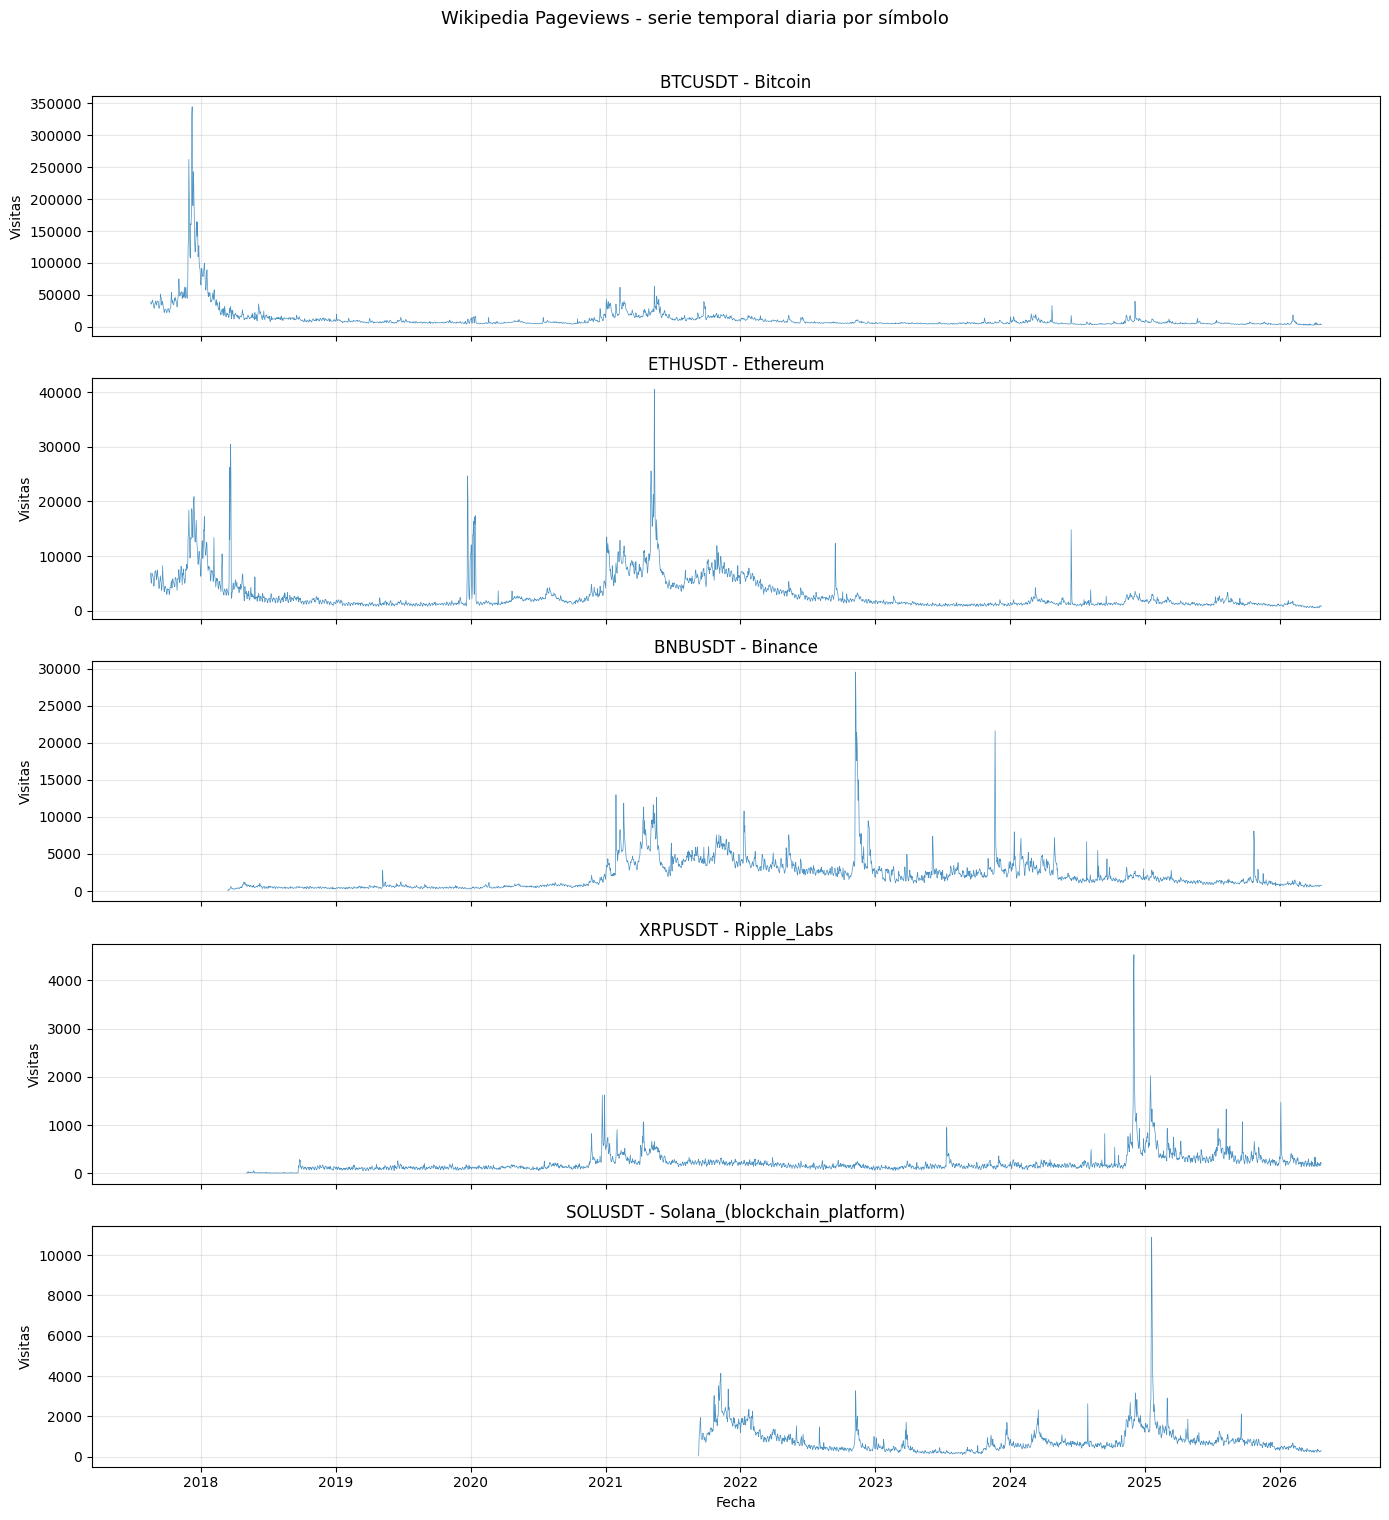

In [8]:
series_dict: dict[str, pd.DataFrame] = {}

if engine:
    for symbol in WIKIPEDIA_SYMBOLS:
        q = text(
            f"""
            SELECT page_date, views
            FROM {WIKIPEDIA_FULL_TABLE}
            WHERE symbol = :symbol
            ORDER BY page_date
            """
        )
        df = pd.read_sql(q, engine, params={"symbol": symbol})
        if not df.empty:
            df["page_date"] = pd.to_datetime(df["page_date"])
            series_dict[symbol] = df

fig_series_path = None

if series_dict:
    fig, axes = plt.subplots(
        len(series_dict), 1,
        figsize=(14, 3 * len(series_dict)),
        sharex=True,
    )
    if len(series_dict) == 1:
        axes = [axes]

    for ax, (symbol, df) in zip(axes, series_dict.items()):
        article = WIKIPEDIA_ARTICLE_MAP.get(symbol, symbol)
        ax.plot(df["page_date"], df["views"], linewidth=0.5, alpha=0.8)
        ax.set_ylabel("Visitas")
        ax.set_title(f"{symbol} - {article}")
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Fecha")
    fig.suptitle("Wikipedia Pageviews - serie temporal diaria por símbolo", fontsize=13, y=1.01)
    plt.tight_layout()
    fig_series_path = WIKIPEDIA_FIGURES_DIR / f"wikipedia_series_diaria_{RUN_STAMP}.png"
    fig.savefig(fig_series_path, dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Sin datos para graficar series temporales.")


## 6. Auditoría de ingesta

Se consulta `ingestion_runs` y `ingestion_events` con los `pipeline_type` vinculados a Wikipedia. El ETL y el orquestador live reutilizan el mismo `pipeline_type` (no se persiste un `*_live` en base de datos), así que el resumen se agrupa por `pipeline_type`. A continuación se listan eventos asociados al `run_id` más reciente.

In [9]:
evidencia_runs_df = pd.DataFrame()
resumen_tipo_pipeline_df = pd.DataFrame()
evidencia_events_df = pd.DataFrame()

if engine:
    q_runs = text(
        """
        SELECT run_id,
               pipeline_type,
               started_at,
               finished_at,
               symbol_count,
               tasks_total,
               success_count,
               failed_count,
               total_rows
        FROM alternative_data.ingestion_runs
        WHERE pipeline_type IN (
            'etl_wikipedia',
            'etl_wikipedia_pageviews',
            'etl_wikipedia_pageviews_backfill',
            'etl_wikipedia_pageviews_repair'
        )
        ORDER BY started_at DESC
        LIMIT 50;
        """
    )
    evidencia_runs_df = pd.read_sql(q_runs, engine)

    if not evidencia_runs_df.empty:
        evidencia_runs_df["run_con_fallo"] = (
            evidencia_runs_df["failed_count"].fillna(0).astype(int) > 0
        )

        resumen_tipo_pipeline_df = (
            evidencia_runs_df.groupby("pipeline_type", as_index=False)
            .agg(
                ejecuciones=("run_id", "count"),
                ultimo_inicio=("started_at", "max"),
                total_filas=("total_rows", "sum"),
                total_fallos_eventos=("failed_count", "sum"),
                ejecuciones_con_fallo=("run_con_fallo", "sum"),
            )
            .sort_values("pipeline_type")
        )
        resumen_tipo_pipeline_df["pct_ejecuciones_con_fallo"] = (
            (resumen_tipo_pipeline_df["ejecuciones_con_fallo"] / resumen_tipo_pipeline_df["ejecuciones"]) * 100.0
        ).round(2)

        latest_run_id = evidencia_runs_df.iloc[0]["run_id"]
        q_events = text(
            """
            SELECT symbol,
                   data_type,
                   status,
                   rows_affected,
                   error_type,
                   error_message,
               detail_message,
                   created_at
            FROM alternative_data.ingestion_events
            WHERE run_id = :run_id
            ORDER BY created_at;
            """
        )
        evidencia_events_df = pd.read_sql(q_events, engine, params={"run_id": str(latest_run_id)})

print("Resumen por pipeline_type (ingestion_runs)")
if not resumen_tipo_pipeline_df.empty:
    display(resumen_tipo_pipeline_df)
else:
    print("Sin runs registrados para los tipos de pipeline Wikipedia en la ventana consultada.")

print(f"\nEventos del último run ({evidencia_runs_df.iloc[0]['run_id'] if not evidencia_runs_df.empty else '-'})")
display(evidencia_events_df) if not evidencia_events_df.empty else print("Sin eventos asociados al último run.")

Resumen por pipeline_type (ingestion_runs)


,pipeline_type,ejecuciones,ultimo_inicio,total_filas,total_fallos_eventos,ejecuciones_con_fallo,pct_ejecuciones_con_fallo
0,etl_wikipedia_pageviews,10,2026-04-24 12:16:42.869123+00:00,27613,5,1,10.0
1,etl_wikipedia_pageviews_repair,3,2026-04-24 12:16:45.571600+00:00,0,0,0,0.0



Eventos del último run (01ce67c2-17e2-4e1f-89e0-0e0034a3cc90)


,symbol,data_type,status,rows_affected,error_type,error_message,detail_message,created_at
0,BTCUSDT,wikipedia_pageviews,skipped,0,None,None,wikipedia_repair: 0 rows reupserted,2026-04-24 12:16:46.799263+00:00
1,ETHUSDT,wikipedia_pageviews,skipped,0,None,None,wikipedia_repair: 0 rows reupserted,2026-04-24 12:16:47.328655+00:00
2,BNBUSDT,wikipedia_pageviews,skipped,0,None,None,wikipedia_repair: 0 rows reupserted,2026-04-24 12:16:47.862950+00:00
3,XRPUSDT,wikipedia_pageviews,skipped,0,None,None,wikipedia_repair: 0 rows reupserted,2026-04-24 12:16:48.405693+00:00
4,SOLUSDT,wikipedia_pageviews,skipped,0,None,None,wikipedia_repair: 0 rows reupserted,2026-04-24 12:16:48.935490+00:00


## 7. Inventario de artefactos Parquet en disco

El inventario contrasta la tabla fact con los ficheros raw esperados bajo `data/01_raw/wikipedia/`. Para cada símbolo se recoge existencia, tamaño, número de filas, número de columnas y rango temporal disponible.

In [10]:
parquet_rows: list[dict] = []

for symbol in WIKIPEDIA_SYMBOLS:
    parquet_path = WIKIPEDIA_RAW_DIR / f"{symbol}_wikipedia_pageviews.parquet"
    if parquet_path.exists():
        tamano_mb = parquet_path.stat().st_size / (1024 * 1024)
        try:
            parquet_df = pd.read_parquet(parquet_path)
            fechas = (
                pd.to_datetime(parquet_df["page_date"], errors="coerce").dropna()
                if "page_date" in parquet_df.columns
                else pd.Series(dtype="datetime64[ns]")
            )
            parquet_rows.append({
                "tipo": "raw_wikipedia_pageviews",
                "simbolo": symbol,
                "titulo_articulo": WIKIPEDIA_ARTICLE_MAP.get(symbol, ""),
                "archivo": parquet_path.name,
                "tamano_mb": round(tamano_mb, 2),
                "filas": len(parquet_df),
                "columnas": len(parquet_df.columns),
                "min_timestamp": fechas.min() if not fechas.empty else None,
                "max_timestamp": fechas.max() if not fechas.empty else None,
            })
        except Exception:
            parquet_rows.append({
                "tipo": "raw_wikipedia_pageviews",
                "simbolo": symbol,
                "titulo_articulo": WIKIPEDIA_ARTICLE_MAP.get(symbol, ""),
                "archivo": parquet_path.name,
                "tamano_mb": round(tamano_mb, 2),
                "filas": None,
                "columnas": None,
                "min_timestamp": None,
                "max_timestamp": None,
            })
    else:
        parquet_rows.append({
            "tipo": "raw_wikipedia_pageviews",
            "simbolo": symbol,
            "titulo_articulo": WIKIPEDIA_ARTICLE_MAP.get(symbol, ""),
            "archivo": parquet_path.name,
            "tamano_mb": None,
            "filas": None,
            "columnas": None,
            "min_timestamp": None,
            "max_timestamp": None,
        })

parquet_inventory_df = pd.DataFrame(parquet_rows)
display(parquet_inventory_df)


,tipo,simbolo,titulo_articulo,archivo,tamano_mb,filas,columnas,min_timestamp,max_timestamp
0,raw_wikipedia_pageviews,BTCUSDT,Bitcoin,BTCUSDT_wikipedia_pageviews.parquet,0.04,3173,10,2017-08-17,2026-04-24
1,raw_wikipedia_pageviews,ETHUSDT,Ethereum,ETHUSDT_wikipedia_pageviews.parquet,0.04,3173,10,2017-08-17,2026-04-24
2,raw_wikipedia_pageviews,BNBUSDT,Binance,BNBUSDT_wikipedia_pageviews.parquet,0.03,2963,10,2018-03-15,2026-04-24
3,raw_wikipedia_pageviews,XRPUSDT,Ripple_Labs,XRPUSDT_wikipedia_pageviews.parquet,0.03,2913,10,2018-05-04,2026-04-24
4,raw_wikipedia_pageviews,SOLUSDT,Solana_(blockchain_platform),SOLUSDT_wikipedia_pageviews.parquet,0.02,1688,10,2021-09-10,2026-04-24


## 8. Exportación de artefactos para reproducibilidad

Las tablas vistas son útiles dentro del cuaderno, pero la memoria del TFG y la auditoría externa necesitan **artefactos persistentes** en disco. En esta celda se vuelca la evidencia tabular bajo `reports/validation/wikipedia/` y la figura bajo `reports/figures/wikipedia/`, con sello UTC (`<stamp>`) en el nombre para no sobrescribir corridas previas (p. ej. `20260604T002100Z` en esta corrida).

- **JSON consolidado:** `wikipedia_validation_<stamp>.json` (metadatos, fecha de corte, símbolos, mapa de artículos, resultado global, `checks`, duplicados, integridad, degradación, inventario *Parquet* y ruta de figura).

- **Diez CSV** en `reports/validation/wikipedia/` (mismo `<stamp>`): `summary`, `resumen_tipo_pipeline`, `resumen_simbolos`, `duplicados`, `integridad`, `degradacion`, `consistencia`, `auditoria`, `eventos`, `parquet_inventory`.

- **Un PNG:** `reports/figures/wikipedia/wikipedia_series_diaria_<stamp>.png` (sección 5).

Al final se imprime el **resultado global** (`PASS`/`FAIL`) y un mini-checklist (auditoría, duplicados, integridad, *Parquet*), seguido de rutas del JSON, CSV y figura. Si el kernel sigue vivo, se libera la conexión con `engine.dispose()` al terminar esta celda.

In [11]:
json_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_{RUN_STAMP}.json"
csv_summary_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_summary_{RUN_STAMP}.csv"
csv_resumen_tipo_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_resumen_tipo_pipeline_{RUN_STAMP}.csv"
csv_resumen_simbolos_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_resumen_simbolos_{RUN_STAMP}.csv"
csv_duplicados_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_duplicados_{RUN_STAMP}.csv"
csv_integridad_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_integridad_{RUN_STAMP}.csv"
csv_degradacion_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_degradacion_{RUN_STAMP}.csv"
csv_consistencia_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_consistencia_{RUN_STAMP}.csv"
csv_auditoria_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_auditoria_{RUN_STAMP}.csv"
csv_eventos_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_eventos_{RUN_STAMP}.csv"
csv_parquet_inv_path = WIKIPEDIA_OUTPUT_DIR / f"wikipedia_validation_parquet_inventory_{RUN_STAMP}.csv"

auditoria_runs_ok = bool(not resumen_tipo_pipeline_df.empty)
duplicados_ok = bool(not duplicados_pk_df.empty and (duplicados_pk_df["duplicados_pk"] == 0).all())
integridad_ok = bool(not integridad_df.empty and len(integridad_df) == len(WIKIPEDIA_SYMBOLS))
parquet_ok = bool(
    not parquet_inventory_df.empty
    and int(parquet_inventory_df["tamano_mb"].notna().sum()) == len(WIKIPEDIA_SYMBOLS)
)

payload = {
    "metadata": run_meta,
    "fecha_corte": FECHA_CORTE,
    "simbolos": list(WIKIPEDIA_SYMBOLS),
    "mapa_articulos": dict(WIKIPEDIA_ARTICLE_MAP),
    "resultado_global": "PASS" if accepted else "FAIL",
    "fallos_accionables": actionable_failures,
    "checks": summary_df.to_dict(orient="records"),
    "completitud_etl": {
        "auditoria_runs_detectada": auditoria_runs_ok,
    },
    "duplicados_pk": {
        "verificado": duplicados_ok,
        "cero_duplicados_todos_simbolos": duplicados_ok,
        "detalle": duplicados_pk_df.to_dict(orient="records") if not duplicados_pk_df.empty else [],
    },
    "integridad_imputaciones": {
        "verificado": integridad_ok,
        "detalle": integridad_df.to_dict(orient="records") if not integridad_df.empty else [],
    },
    "degradacion_operativa": {
        "detalle": degradacion_df.to_dict(orient="records") if not degradacion_df.empty else [],
    },
    "inventario_parquet": {
        "archivos_encontrados": int((parquet_inventory_df["tamano_mb"].notna()).sum()) if not parquet_inventory_df.empty else 0,
        "archivos_esperados": len(parquet_inventory_df) if not parquet_inventory_df.empty else 0,
        "detalle": parquet_inventory_df.to_dict(orient="records") if not parquet_inventory_df.empty else [],
    },
    "figuras": {
        "series_diaria_png": str(fig_series_path) if fig_series_path else None,
    },
}

json_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
summary_df.to_csv(csv_summary_path, index=False)
if not resumen_tipo_pipeline_df.empty:
    resumen_tipo_pipeline_df.to_csv(csv_resumen_tipo_path, index=False)
if not resumen_simbolos_df.empty:
    resumen_simbolos_df.to_csv(csv_resumen_simbolos_path, index=False)
if not duplicados_pk_df.empty:
    duplicados_pk_df.to_csv(csv_duplicados_path, index=False)
if not integridad_df.empty:
    integridad_df.to_csv(csv_integridad_path, index=False)
if not degradacion_df.empty:
    degradacion_df.to_csv(csv_degradacion_path, index=False)
if not consistencia_df.empty:
    consistencia_df.to_csv(csv_consistencia_path, index=False)
if not evidencia_runs_df.empty:
    evidencia_runs_df.rename(columns=COLUMNAS_INGESTION_RUNS_ES).to_csv(csv_auditoria_path, index=False)
if not evidencia_events_df.empty:
    evidencia_events_df.rename(columns=COLUMNAS_INGESTION_EVENTS_ES).to_csv(csv_eventos_path, index=False)
if not parquet_inventory_df.empty:
    parquet_inventory_df.to_csv(csv_parquet_inv_path, index=False)

print(f"Resultado global: {'PASS' if accepted else 'FAIL'}")
print(f"Auditoría ingestion_runs: {'OK' if auditoria_runs_ok else 'PENDIENTE'}")
print(
    f"Duplicados = 0 verificado: {'OK' if duplicados_ok else 'PENDIENTE'}"
)
print(
    f"Integridad por símbolo: {'OK' if integridad_ok else 'PENDIENTE'}"
)
print(f"Inventario Parquet raw: {'OK' if parquet_ok else 'PENDIENTE'}")
print(f"Evidencia JSON: {json_path}")
print(f"Resumen de comprobaciones CSV: {csv_summary_path}")
if not resumen_tipo_pipeline_df.empty:
    print(f"Resumen por tipo de pipeline CSV: {csv_resumen_tipo_path}")
if not resumen_simbolos_df.empty:
    print(f"Resumen por símbolo CSV: {csv_resumen_simbolos_path}")
if not duplicados_pk_df.empty:
    print(f"Duplicados PK CSV: {csv_duplicados_path}")
if not integridad_df.empty:
    print(f"Integridad e imputaciones CSV: {csv_integridad_path}")
if not degradacion_df.empty:
    print(f"Degradación operativa CSV: {csv_degradacion_path}")
if not consistencia_df.empty:
    print(f"Consistencia CSV: {csv_consistencia_path}")
if not evidencia_runs_df.empty:
    print(f"Auditoría runs CSV (nombres ES): {csv_auditoria_path}")
if not evidencia_events_df.empty:
    print(f"Eventos CSV (nombres ES): {csv_eventos_path}")
if not parquet_inventory_df.empty:
    print(f"Inventario Parquet CSV: {csv_parquet_inv_path}")
if fig_series_path:
    print(f"Figura series diarias PNG: {fig_series_path}")

if engine is not None:
    engine.dispose()


Resultado global: PASS
Auditoría ingestion_runs: OK
Duplicados = 0 verificado: OK
Integridad por símbolo: OK
Inventario Parquet raw: OK
Evidencia JSON: /app/reports/validation/wikipedia/wikipedia_validation_20260604T002100Z.json
Resumen de comprobaciones CSV: /app/reports/validation/wikipedia/wikipedia_validation_summary_20260604T002100Z.csv
Resumen por tipo de pipeline CSV: /app/reports/validation/wikipedia/wikipedia_validation_resumen_tipo_pipeline_20260604T002100Z.csv
Resumen por símbolo CSV: /app/reports/validation/wikipedia/wikipedia_validation_resumen_simbolos_20260604T002100Z.csv
Duplicados PK CSV: /app/reports/validation/wikipedia/wikipedia_validation_duplicados_20260604T002100Z.csv
Integridad e imputaciones CSV: /app/reports/validation/wikipedia/wikipedia_validation_integridad_20260604T002100Z.csv
Degradación operativa CSV: /app/reports/validation/wikipedia/wikipedia_validation_degradacion_20260604T002100Z.csv
Consistencia CSV: /app/reports/validation/wikipedia/wikipedia_valid

## 9. Conclusiones

Para el universo `{BTCUSDT, ETHUSDT, BNBUSDT, XRPUSDT, SOLUSDT}` y fecha de corte **2026-02-28**, esta ejecución (`stamp` `20260604T002100Z`, `fecha_hora_utc` **2026-06-04 00:21 UTC**) deja una lectura favorable de la ingesta de Wikipedia Pageviews.

1. **Ingesta estructural**: resultado global `PASS`; nueve comprobaciones en `PASS` (0 `FAIL`, 0 `SKIP`); sin fallos accionables en el validador.

2. **Cobertura e integridad**: `alternative_data.fact_wikipedia_pageviews` resume **13,910** filas entre **2017-08-17** y **2026-04-24**; **0** duplicados PK; **13,905** filas reales y **5** imputadas (una por símbolo). Degradación operativa: **1** fila `needs_repair` por activo en esta corrida.

3. **Auditoría y artefactos**: **13** ejecuciones en `ingestion_runs` (**10** `etl_wikipedia_pageviews`, **3** `etl_wikipedia_pageviews_repair`; **27,613** filas reportadas en el pipeline principal, **10 %** con fallo de evento); **5/5** *Parquet* raw; JSON + diez CSV y `wikipedia_series_diaria_20260604T002100Z.png` bajo `reports/validation/wikipedia/` y `reports/figures/wikipedia/`.

**Nota.** Resultado global, métricas SQL y rutas con `stamp` dependen del estado del proyecto al ejecutar el cuaderno; en otra corrida pueden cambiar.